Sustainable Consumption & Waste Management Analytics

Import Libraries

In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.cluster import KMeans

Load Dataset

In [85]:
df = pd.read_excel(r"C:\Users\Vimal\Desktop\Monalisa\PROJECT\Sustainable Consumption & Waste Management\country_level_data.xlsx")

print(df.shape)
df.head()

(218, 110)


,Country code,Region,Country name,Income group (waste generation year),Income group (2022),GDP,Population in waste generation year,MSW generation - year reported,MSW generation (t/y),MSW generation - point of measurement,...,Existence of EPR system for waste batteries,Existence of EPR system for other waste,EPR leadership model (private or government led),Mandatory or voluntary EPR,Operational status of EPR system,Existence of DRS for beverage containers,Geographical scope of DRS,DRS container scope,Driver of participation in DRS,Operational status of DRS
0,iso3c,region_id,country_name,income_id,income_id_2022,gdp,population_number_of_people,msw_total_msw_generation_year,msw_total_msw_generated_tonnes_year,msw_total_msw_generated_point_of_measurement,...,epr_(3)_batteries,epr_(6)_other,epr_Private_(industry_led)_or_public_(governme...,epr_mandatory_or_voluntary_scheme,epr_Operational_status,drs_for_beverage_containers_present,drs_geographical_scope,drs_containers_types,drs_mandatory_vs_voluntary,drs_operational_status
1,AFG,S. Asia,Afghanistan,LIC,LIC,18753456497.82,35174083,2017,4148162,Not stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ALB,Eur. & Cent. Asia,Albania,UMIC,UMIC,18032009220,2865704,2021,754094,"Point of treatment or disposal (Landfill, dump...",...,Yes,Yes,Industry-led,Mandatory,Legally-binding regulations in place,NaN,NaN,NaN,NaN,NaN
3,DZA,Mid. East & N. Africa,Algeria,LMIC,LMIC,164873415325.200012,43685420,2020,13500000,Not stated,...,NaN,NaN,NaN,Both,Legally-binding regulations in place,NaN,NaN,NaN,NaN,NaN
4,ASM,E. Asia & Pacific,American Samoa,UMIC,HIC,647000000,50563,2019,17348.1653,Not stated,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [86]:
print(df.columns.tolist())

['Country code', 'Region', 'Country name ', 'Income group (waste generation year)', 'Income group (2022)', 'GDP', 'Population in waste generation year', 'MSW generation - year reported', 'MSW generation (t/y)', 'MSW generation - point of measurement', 'MSW generation (kg/capita/day)', 'MSW generation - projected 2022 (t/year)', 'Population in 2022', 'MSW generation - projected 2022 (kg/cap/day)', 'MSW generation - projected 2030 (t/y)', 'Population in 2030', 'MSW generation - projected 2030 (kg/cap/day)', 'MSW generation - projected 2040 (t/y)', 'Population in 2040', 'MSW generation - projected 2040 (kg/cap/day)', 'MSW generation - projected 2050 (t/y)', 'Population in 2050', 'MSW generation - projected 2050 (kg/cap/day)', 'Composition - food  (% weight MSW)', 'Composition - glass  (% weight MSW)', 'Composition - metal (% weight MSW)', 'Composition - paper & cardboard (% weight MSW)', 'Composition - plastic (% weight MSW)', 'Composition - rubber & leather  (% weight MSW) ', 'Compositio

Clean Column Names

In [87]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace('\n', ' ', regex=True)
df.columns = df.columns.str.replace(r'\s+', ' ', regex=True)

print(df.columns.tolist())

['Country code', 'Region', 'Country name', 'Income group (waste generation year)', 'Income group (2022)', 'GDP', 'Population in waste generation year', 'MSW generation - year reported', 'MSW generation (t/y)', 'MSW generation - point of measurement', 'MSW generation (kg/capita/day)', 'MSW generation - projected 2022 (t/year)', 'Population in 2022', 'MSW generation - projected 2022 (kg/cap/day)', 'MSW generation - projected 2030 (t/y)', 'Population in 2030', 'MSW generation - projected 2030 (kg/cap/day)', 'MSW generation - projected 2040 (t/y)', 'Population in 2040', 'MSW generation - projected 2040 (kg/cap/day)', 'MSW generation - projected 2050 (t/y)', 'Population in 2050', 'MSW generation - projected 2050 (kg/cap/day)', 'Composition - food (% weight MSW)', 'Composition - glass (% weight MSW)', 'Composition - metal (% weight MSW)', 'Composition - paper & cardboard (% weight MSW)', 'Composition - plastic (% weight MSW)', 'Composition - rubber & leather (% weight MSW)', 'Composition - w

Selecting Important Columns

In [88]:
# ===============================
# SAFE COLUMN EXTRACTION
# ===============================

def find_col(keywords):
    for col in df.columns:
        for key in keywords:
            if key.lower() in col.lower():
                return col
    return None

col_map = {
    'country': find_col(['country name', 'country']),
    'region': find_col(['region']),
    'population': find_col(['population in 2022']),
    'waste_total': find_col(['msw generation (t/year)', 'msw generation (t']),
    'waste_per_capita': find_col(['kg/capita']),
    'recycled_waste': find_col(['recycling (t/year)', 'recycling (t']),
    'recycling_rate': find_col(['treatment - recycling']),
    'dump_rate': find_col(['open dump']),
    'plastic_pct': find_col(['composition - plastic']),
    'food_pct': find_col(['composition - food'])
}

# 🔍 DEBUG: see what matched
for k, v in col_map.items():
    print(f"{k} → {v}")

# ===============================
# REMOVE MISSING
# ===============================
col_map = {k: v for k, v in col_map.items() if v is not None}

# ===============================
# SELECT + RENAME
# ===============================
df = df[list(col_map.values())]
df.rename(columns={v: k for k, v in col_map.items()}, inplace=True)

# ===============================
# ENSURE ALL REQUIRED COLUMNS EXIST
# ===============================
required_cols = [
    'country','region','population','waste_total',
    'waste_per_capita','recycled_waste',
    'recycling_rate','dump_rate','plastic_pct','food_pct'
]

for col in required_cols:
    if col not in df.columns:
        print(f"⚠️ Missing column created: {col}")
        df[col] = 0

# ===============================
# FINAL CHECK
# ===============================
print(df.head())
print(df.columns)

country → Country code
region → Region
population → Population in 2022
waste_total → MSW generation (t/y)
waste_per_capita → MSW generation (kg/capita/day)
recycled_waste → MSW - separately collected for recycling (t/y)
recycling_rate → Treatment - recycling (% weight MSW generated)
dump_rate → Treatment - open dump (% weight MSW generated)
plastic_pct → Composition - plastic (% weight MSW)
food_pct → Composition - food (% weight MSW)
  country                 region                        population  \
0   iso3c              region_id  population_number_of_people_2022   
1     AFG                S. Asia                          40292816   
2     ALB      Eur. & Cent. Asia                           2833567   
3     DZA  Mid. East & N. Africa                          45123436   
4     ASM      E. Asia & Pacific                             48782   

                           waste_total  \
0  msw_total_msw_generated_tonnes_year   
1                              4148162   
2             

In [89]:


print(df.columns.tolist())
df.shape

['country', 'region', 'population', 'waste_total', 'waste_per_capita', 'recycled_waste', 'recycling_rate', 'dump_rate', 'plastic_pct', 'food_pct']


(218, 10)

In [90]:
df.head()

,country,region,population,waste_total,waste_per_capita,recycled_waste,recycling_rate,dump_rate,plastic_pct,food_pct
0,iso3c,region_id,population_number_of_people_2022,msw_total_msw_generated_tonnes_year,msw_total_msw_generated_kg_per_cap_per_day,separation_amount_of_material_collected_for_re...,waste_treatment_recycling_percent,waste_treatment_open_dumpsite_percent,composition_msw_plastic_percent,composition_msw_food_organic_waste_percent
1,AFG,S. Asia,40292816,4148162,0.323102,NaN,0.189,NaN,0.1175,0.5217
2,ALB,Eur. & Cent. Asia,2833567,754094,0.720944,154934,0.173337,0.000867,0.092,0.581
3,DZA,Mid. East & N. Africa,45123436,13500000,0.846651,1208643,0.07,0.6,0.1531,0.5361
4,ASM,E. Asia & Pacific,48782,17348.1653,0.94,NaN,NaN,NaN,0.128,0.197


Data Cleaning

In [95]:
# Handle missing values


df = df.replace(" ", np.nan)

df = df.apply(pd.to_numeric, errors='ignore')

df = df.fillna(df.median(numeric_only=True))


df = df.iloc[1:].reset_index(drop=True) # Removes first row

df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   country               216 non-null    object  
 1   region                216 non-null    object  
 2   population            216 non-null    float64 
 3   waste_total           216 non-null    float64 
 4   waste_per_capita      216 non-null    float64 
 5   recycled_waste        216 non-null    float64 
 6   recycling_rate        216 non-null    float64 
 7   dump_rate             216 non-null    float64 
 8   plastic_pct           216 non-null    float64 
 9   food_pct              216 non-null    float64 
 10  waste_per_person      216 non-null    float64 
 11  sustainability_index  216 non-null    float64 
 12  sustainability_level  30 non-null     category
dtypes: category(1), float64(10), object(2)
memory usage: 20.7+ KB


C:\Users\Vimal\AppData\Local\Temp\ipykernel_22852\37221498.py:6: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [92]:
df.head()

,country,region,population,waste_total,waste_per_capita,recycled_waste,recycling_rate,dump_rate,plastic_pct,food_pct
0,AFG,S. Asia,40292816,4148162,0.323102,NaN,0.189,NaN,0.1175,0.5217
1,ALB,Eur. & Cent. Asia,2833567,754094,0.720944,154934,0.173337,0.000867,0.092,0.581
2,DZA,Mid. East & N. Africa,45123436,13500000,0.846651,1208643,0.07,0.6,0.1531,0.5361
3,ASM,E. Asia & Pacific,48782,17348.1653,0.94,NaN,NaN,NaN,0.128,0.197
4,AND,Eur. & Cent. Asia,79116,37950,1.339663,6386.38,0.399,NaN,NaN,0.208


Numeric Conversion

In [93]:
df['waste_per_capita'] = df['waste_per_capita'].astype(str)

# Remove text like 'kg', spaces, etc.
df['waste_per_capita'] = df['waste_per_capita'].str.replace('[^0-9.]', '', regex=True)

#convert to numeric
df['waste_per_capita'] = pd.to_numeric(df['waste_per_capita'], errors='coerce')


cols_to_convert = ['waste_total', 'population', 'recycling_rate', 'dump_rate', 'plastic_pct']
for col in cols_to_convert:
    df[col] = pd.to_numeric(df[col], errors='coerce')



Feature Engineering:

Dataset already has waste — now convert it into project metrics

In [96]:
# Waste per capita already exists
# Waste per person 

df['waste_per_person'] = df['waste_total'] / (df['population'] + 1)

# Sustainability Index (Key Metric)



df['sustainability_index'] = (
    (df['recycling_rate'] * 0.6)
    - (df['dump_rate'] * 0.25)
    - (df['plastic_pct'] * 0.15)
)

# Normalize safely
df['sustainability_index'] = (
    df['sustainability_index'] - df['sustainability_index'].min()
) / (
    df['sustainability_index'].max() - df['sustainability_index'].min() + 1e-6
)

# ✅ BETTER TARGET (balanced classes)
df['sustainability_level'] = pd.qcut(
    df['sustainability_index'],
    q=3,
    labels=['Low', 'Medium', 'High'],
    duplicates='drop'
)
df = df.dropna(subset=['sustainability_level'])
print(df.shape)
print(df['sustainability_level'].value_counts())


(216, 13)
sustainability_level
Low       72
Medium    72
High      72
Name: count, dtype: int64


In [ ]:
KPIs Calculations

In [76]:
total_waste = df['waste_total'].sum()
avg_recycling = df['recycling_rate'].mean()
avg_waste_capita = df['waste_per_capita'].mean()

print("Total Waste:", total_waste)
print("Avg Recycling Rate:", avg_recycling)
print("Avg Waste per Capita:", avg_waste_capita)

Total Waste: 222910667.8846422
Avg Recycling Rate: 0.1184090535098575
Avg Waste per Capita: 0.96432046240884


In [ ]:
EDA ( Exploratory Data Analysis)

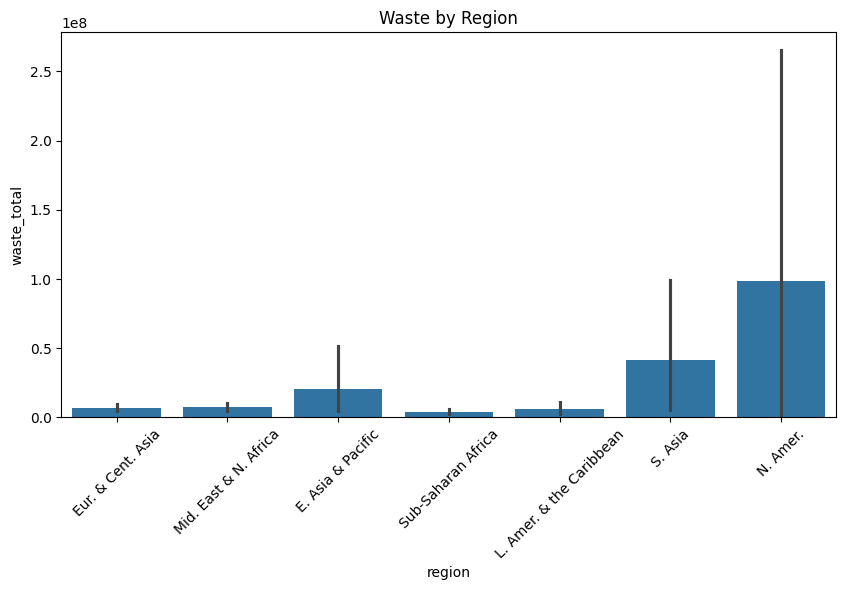

In [97]:
# Waste by region

plt.figure(figsize=(10,5))
sns.barplot(data=df, x='region', y='waste_total')
plt.xticks(rotation=45)
plt.title("Waste by Region")
plt.show()




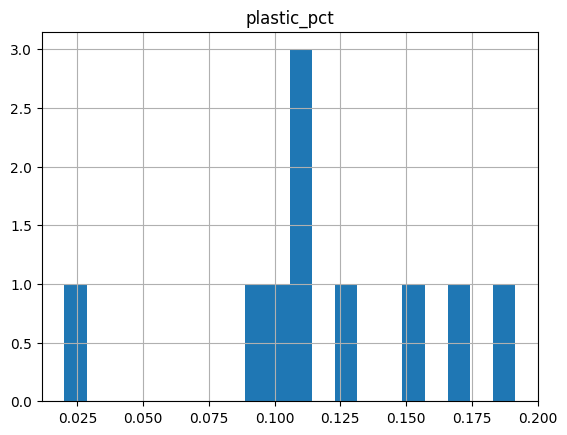

In [78]:
# Plastic vs Food composition

df[['plastic_pct','food_pct']].hist(bins=20)
plt.show()

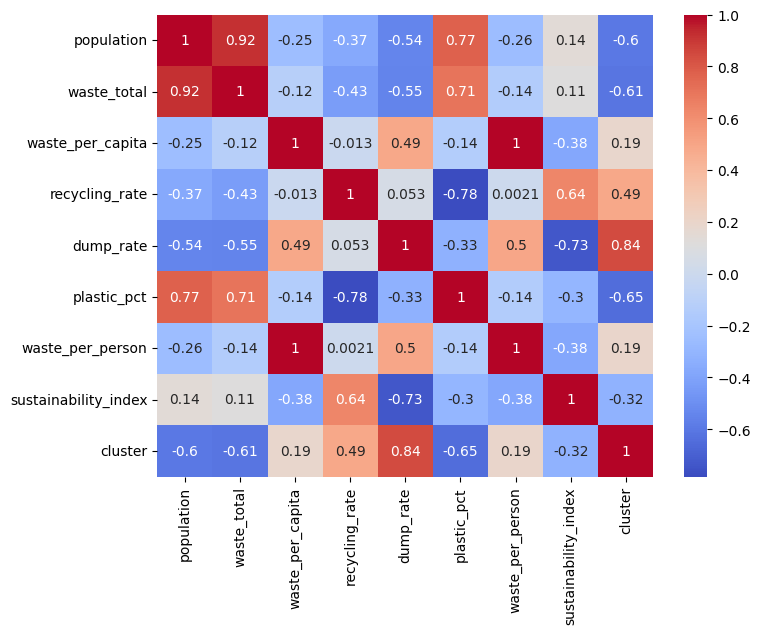

In [79]:

#Correlation

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [83]:
print("Final dataset used:", X.shape)

Final dataset used: (10, 3)


Machine Learning (Classification)

In [98]:


# Select features

features = ['recycling_rate','plastic_pct','dump_rate']

X = df[features].copy()
y = df['sustainability_level'].copy()

# Convert everything to numeric 

for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Replace inf values
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values in X
X = X.fillna(X.median())

# If still any NaN → fill with 0 
X = X.fillna(0)

# Fix target variable
y = y.astype(str)

# Replace invalid or missing labels
y = y.replace(['nan', 'None', ''], 'Medium')

# Final check
print("NaN in X:", X.isnull().sum().sum())
print("NaN in y:", y.isnull().sum())

# TRAIN TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

# MODEL


model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

print("Accuracy:", model.score(X_test, y_test))

NaN in X: 0
NaN in y: 0
Accuracy: 0.9722222222222222


In [99]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", y.unique())
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

X shape: (216, 3)
y shape: (216,)
Classes: ['High' 'Low' 'Medium']
Train size: (108, 3)
Test size: (108, 3)


In [100]:
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9722222222222222


Clustering (Segmentation)

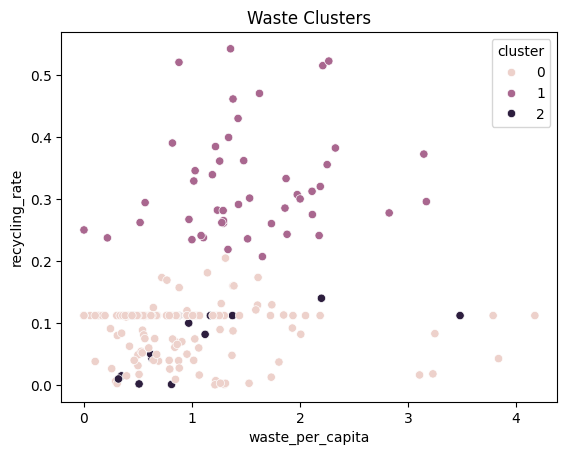

In [101]:
kmeans = KMeans(n_clusters=3)

df['cluster'] = kmeans.fit_predict(X)

sns.scatterplot(
    x='waste_per_capita',
    y='recycling_rate',
    hue='cluster',
    data=df
)
plt.title("Waste Clusters")
plt.show()

Save Outputs

In [104]:
df.to_csv("cleaned_waste_data.csv", index=False)

metrics = df.groupby('region').agg({
    'waste_total':'sum',
    'recycling_rate':'mean',
    'sustainability_index':'mean'
}).reset_index()

metrics.to_csv("waste_metrics.csv", index=False)

Key Insights

In [105]:
print("""
Insights:
1. Regions with higher recycling rates show better sustainability.
2. Plastic waste strongly impacts sustainability index.
3. High dump rates reduce sustainability scores.
4. Clustering reveals 3 types of regions: high, medium, low sustainability.
""")


Insights:
1. Regions with higher recycling rates show better sustainability.
2. Plastic waste strongly impacts sustainability index.
3. High dump rates reduce sustainability scores.
4. Clustering reveals 3 types of regions: high, medium, low sustainability.



Save model

In [106]:
import joblib
joblib.dump(model, "model.pkl")

['model.pkl']

Predict Model

In [107]:
print(model.feature_names_in_)

['recycling_rate' 'plastic_pct' 'dump_rate']


In [108]:


# High case (Input values)
recycling = 70
plastic = 5
dump = 2


# Create DataFrame (MATCH EXACT FEATURE ORDER)
input_df = pd.DataFrame([[recycling, plastic, dump]],
                        columns=['recycling_rate', 'plastic_pct', 'dump_rate'])

# Prediction
prediction = model.predict(input_df)

print("Prediction:", prediction[0])

Prediction: High
